# Cross-region survival comparison (PROGNOSER)

Mirror of the classifier comparison notebook for time-to-conversion: C-index and
time-dependent AUC at {24, 36, 60} months across PROGNOSER models (Cox, RSF, LSTM-Surv).
Same 7 pre-registered H1/H2/H3 contrasts; paired bootstrap on subject-level resampling
(DeLong does not apply to C-index).

In [ ]:
# === Papermill parameters (injected by run_experiment.py) ===
# Safe interactive defaults: None keeps the original Jupyter behaviour
# (interactive checkpoint/threshold prompts, JSON-config loading).
EXPERIMENT_ID = None
MODE = None
MODEL = None
DATASET = None
SEED = 42
GAAE_CHECKPOINT_PATH = None   # None -> interactive checkpoint picker
THRESHOLD_MODE = None         # None -> interactive prompt; else youden | best-f1 | fixed
FIXED_THRESHOLD = None        # required when THRESHOLD_MODE is fixed
WANDB_ENABLED = True          # W&B logging is on by default
OUTPUT_DIR = None             # defaults to outputs/<experiment-id>/ when run standalone
RESOLVED_CONFIG = None        # merged hyperparameter dict; overrides on-disk JSON when set
RUN_DIR = None                # set by the runner: where run_summary.json / artifacts go
RUN_NAME = None               # set by the runner: the W&B run name


In [1]:
import sys
from pathlib import Path
REPO_ROOT = Path("/mnt/e/fyassine/ad-early-detection")
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

In [2]:
from CLASSIFIER.common.seeding import set_seed, make_rng
SEED = 42
set_seed(SEED)
rng = make_rng(SEED)

In [3]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import pandas as pd

from CLASSIFIER.common.comparison import holm_correction, paired_bootstrap_ci
from CLASSIFIER.common.contrasts import CONTRASTS, regions_referenced
from PROGNOSER.common.metrics import c_index, time_dependent_auc

## Configuration

In [4]:
USE_MOCK = True

MODELS = ["cox", "rsf", "lstm_surv"]
REGIONS = list(regions_referenced())
SEEDS = [42, 43, 44]
EVAL_TIMES = (24, 36, 60)
N_BOOT = 1000
ALPHA = 0.05

REPO_ROOT = Path("/mnt/e/fyassine/ad-early-detection")
OUTPUTS_DIR = REPO_ROOT / "PROGNOSER" / "outputs"
RESULTS_DIR = REPO_ROOT / "CLASSIFIER" / "notebooks" / "COMPARISON" / "_results_survival"
RESULTS_DIR.mkdir(exist_ok=True)

## Load survival predictions

Per-cell parquet schema: `subject_id, duration, event, risk, seed`. Same DELCODE
shared-split guarantee - subjects identical across cells of the same seed.

In [5]:
def _mock_event_duration(seed: int, n_test: int = 47) -> tuple[np.ndarray, np.ndarray]:
    """(duration, event) depend only on seed - paired across all (model, region) cells."""
    rng_l = np.random.default_rng(0xC0DE0000 + seed)
    duration = rng_l.uniform(6, 72, size=n_test)
    event = rng_l.integers(0, 2, size=n_test)
    return duration, event


def _mock_survival(region: str, model: str, seed: int, n_test: int = 47) -> pd.DataFrame:
    duration, event = _mock_event_duration(seed, n_test)
    r_seed = (hash((region, model, seed)) & 0xFFFFFFFF)
    rng_local = np.random.default_rng(r_seed)
    region_cindex = {
        "wholebrain":            0.72,
        "dmn":                   0.70,
        "hippo":                 0.65,
        "limbic":                0.63,
        "dan":                   0.58,
        "dmn-hippo":             0.74,
        "dmn-limbic":            0.71,
        "dmn-hippo-limbic":      0.76,
        "dmn-hippo-limbic-dan":  0.75,
    }
    model_offsets = {"cox": -0.02, "rsf": 0.0, "lstm_surv": 0.02}
    target = region_cindex.get(region, 0.65) + model_offsets.get(model, 0.0)
    base_risk = rng_local.normal(size=n_test)
    risk = base_risk + (event - 0.5) * (target - 0.5) * 5.0
    return pd.DataFrame({
        "subject_id": [f"sub-{i:04d}" for i in range(n_test)],
        "duration": duration,
        "event": event,
        "risk": risk,
        "seed": seed,
    })


def load_cell(model: str, region: str, seed: int) -> pd.DataFrame:
    if USE_MOCK:
        return _mock_survival(region, model, seed)
    path = OUTPUTS_DIR / f"{model}-{region}-seed{seed}" / "predictions_test.parquet"
    if not path.exists():
        raise FileNotFoundError(f"Missing predictions: {path}")
    return pd.read_parquet(path)


cells: dict[tuple[str, str, int], pd.DataFrame] = {}
for m in MODELS:
    for r in REGIONS:
        for s in SEEDS:
            cells[(m, r, s)] = load_cell(m, r, s)
print(f"Loaded {len(cells)} cells")

Loaded 63 cells


## Per-cell C-index summary

In [6]:
rows = []
for (m, r, s), df in cells.items():
    ci = c_index(df["duration"].values, df["event"].values, df["risk"].values)
    rows.append({"model": m, "region": r, "seed": s, "c_index": ci, "n": len(df)})

per_cell = pd.DataFrame(rows)
per_cell_summary = (
    per_cell.groupby(["model", "region"])
    .agg(c_mean=("c_index", "mean"), c_std=("c_index", "std"))
    .reset_index()
)
per_cell_summary.to_csv(RESULTS_DIR / "per_cell_c_index.csv", index=False)
per_cell_summary

,model,region,c_mean,c_std
0,cox,dmn,0.596906,0.054100
1,cox,dmn-hippo,0.582695,0.146075
2,cox,dmn-hippo-limbic,0.554451,0.039683
3,cox,dmn-hippo-limbic-dan,0.610781,0.027856
4,cox,dmn-limbic,0.649183,0.085187
5,cox,hippo,0.596125,0.050725
6,cox,wholebrain,0.556226,0.031177
7,lstm_surv,dmn,0.607218,0.011005
8,lstm_surv,dmn-hippo,0.616923,0.080095
9,lstm_surv,dmn-hippo-limbic,0.586359,0.025926


## Pre-registered contrasts on C-index (paired bootstrap + Holm)

In [7]:
def pool_across_seeds(model: str, region: str) -> pd.DataFrame:
    return pd.concat([cells[(model, region, s)] for s in SEEDS], ignore_index=True)


def c_index_metric(labels_packed: np.ndarray, risk: np.ndarray) -> float:
    """Adapter so paired_bootstrap_ci can call PROGNOSER.common.metrics.c_index.

    labels_packed: int array where each entry encodes duration*2 + event using a
    sentinel pairing. To preserve duration as float, callers should instead pass
    structured data via the wrapper below.
    """
    raise NotImplementedError("Use c_index_pair via the paired bootstrap wrapper below.")


def paired_bootstrap_c_index(
    df_a: pd.DataFrame, df_b: pd.DataFrame, *, n_boot: int, rng: np.random.Generator,
) -> tuple[float, float, float, float]:
    """Paired bootstrap on Delta-c-index across the same subjects.
    Returns (delta, ci_lo, ci_hi, two-sided p from bootstrap quantile crossing zero)."""
    T = df_a["duration"].values
    E = df_a["event"].values
    risk_a = df_a["risk"].values
    risk_b = df_b["risk"].values
    n = len(T)
    point = c_index(T, E, risk_a) - c_index(T, E, risk_b)
    deltas = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        try:
            d = c_index(T[idx], E[idx], risk_a[idx]) - c_index(T[idx], E[idx], risk_b[idx])
        except (ValueError, ZeroDivisionError):
            continue
        if np.isnan(d):
            continue
        deltas.append(d)
    deltas = np.asarray(deltas)
    if len(deltas) < 0.5 * n_boot:
        raise ValueError("Bootstrap produced too many failures - inspect inputs.")
    lo = float(np.quantile(deltas, 0.025))
    hi = float(np.quantile(deltas, 0.975))
    # Two-sided percentile p: 2 * min(fraction <= 0, fraction >= 0)
    p = 2.0 * min((deltas <= 0).mean(), (deltas >= 0).mean())
    return float(point), lo, hi, float(p)


contrast_rows = []
for model in MODELS:
    pvals = []
    raw = []
    for c in CONTRASTS:
        df_a = pool_across_seeds(model, c.region_a)
        df_b = pool_across_seeds(model, c.region_b)
        assert np.array_equal(df_a["event"].values, df_b["event"].values)
        delta, lo, hi, p = paired_bootstrap_c_index(
            df_a, df_b, n_boot=N_BOOT, rng=make_rng(SEED),
        )
        raw.append({
            "model": model, "contrast": c.name, "hypothesis": c.hypothesis,
            "region_a": c.region_a, "region_b": c.region_b,
            "delta_c": delta, "ci_lo": lo, "ci_hi": hi, "p_raw": p,
        })
        pvals.append(p)
    rejected, adj_p = holm_correction(np.array(pvals), alpha=ALPHA)
    for i, row in enumerate(raw):
        row["p_holm"] = float(adj_p[i])
        row["rejected"] = bool(rejected[i])
        contrast_rows.append(row)

contrast_df = pd.DataFrame(contrast_rows)
contrast_df.to_csv(RESULTS_DIR / "contrast_table_c_index.csv", index=False)
contrast_df

,model,contrast,hypothesis,region_a,region_b,delta_c,ci_lo,ci_hi,p_raw,p_holm,rejected
0,cox,H1_wholebrain_vs_dmn,H1,wholebrain,dmn,-0.031974,-0.123789,0.058983,0.498,1.0,False
1,cox,H1_wholebrain_vs_best_memory,H1,wholebrain,dmn-hippo-limbic,-0.001390,-0.087979,0.097617,0.942,1.0,False
2,cox,H2_dmn_vs_dmn_hippo,H2,dmn,dmn-hippo,0.014674,-0.088819,0.111319,0.792,1.0,False
3,cox,H2_dmn_vs_dmn_limbic,H2,dmn,dmn-limbic,-0.055298,-0.141117,0.027793,0.198,1.0,False
4,cox,H2_dmn_hippo_vs_dmn_hippo_limbic,H2,dmn-hippo,dmn-hippo-limbic,0.015910,-0.070136,0.110192,0.706,1.0,False
5,cox,H3_memory_vs_memory_plus_dan,H3,dmn-hippo-limbic,dmn-hippo-limbic-dan,-0.051591,-0.147453,0.043806,0.276,1.0,False
6,cox,SANITY_hippo_vs_dmn_hippo,sanity,hippo,dmn-hippo,0.016837,-0.072376,0.103949,0.702,1.0,False
7,rsf,H1_wholebrain_vs_dmn,H1,wholebrain,dmn,-0.051745,-0.138912,0.039450,0.278,1.0,False
8,rsf,H1_wholebrain_vs_best_memory,H1,wholebrain,dmn-hippo-limbic,-0.059314,-0.138930,0.025222,0.178,1.0,False
9,rsf,H2_dmn_vs_dmn_hippo,H2,dmn,dmn-hippo,0.012512,-0.063552,0.096628,0.812,1.0,False


## Time-dependent AUC at {24, 36, 60} months

Requires training-set survival info for IPCW weighting (`time_dependent_auc` needs T_train/E_train). For mock pipeline validation we reuse the test cohort itself as a placeholder training reference.

In [8]:
auc_rows = []
for (m, r, s), df in cells.items():
    aucs = time_dependent_auc(
        df["duration"].values, df["event"].values,
        df["duration"].values, df["event"].values,
        df["risk"].values, times=EVAL_TIMES,
    )
    for t, a in aucs.items():
        auc_rows.append({"model": m, "region": r, "seed": s, "t_months": int(t), "auc": a})

td_auc = pd.DataFrame(auc_rows)
td_summary = (
    td_auc.groupby(["model", "region", "t_months"])
    .agg(auc_mean=("auc", "mean"), auc_std=("auc", "std"))
    .reset_index()
)
td_summary.to_csv(RESULTS_DIR / "per_cell_td_auc.csv", index=False)
td_summary.head(12)

,model,region,t_months,auc_mean,auc_std
0,cox,dmn,24,0.521793,0.099924
1,cox,dmn,36,0.588380,0.045507
2,cox,dmn,60,0.644596,0.069470
3,cox,dmn-hippo,24,0.542427,0.211657
4,cox,dmn-hippo,36,0.581001,0.127970
5,cox,dmn-hippo,60,0.544414,0.086208
6,cox,dmn-hippo-limbic,24,0.543467,0.024816
7,cox,dmn-hippo-limbic,36,0.555758,0.078957
8,cox,dmn-hippo-limbic,60,0.556608,0.054779
9,cox,dmn-hippo-limbic-dan,24,0.569709,0.049383


## Forest plot - C-index per (model, region)

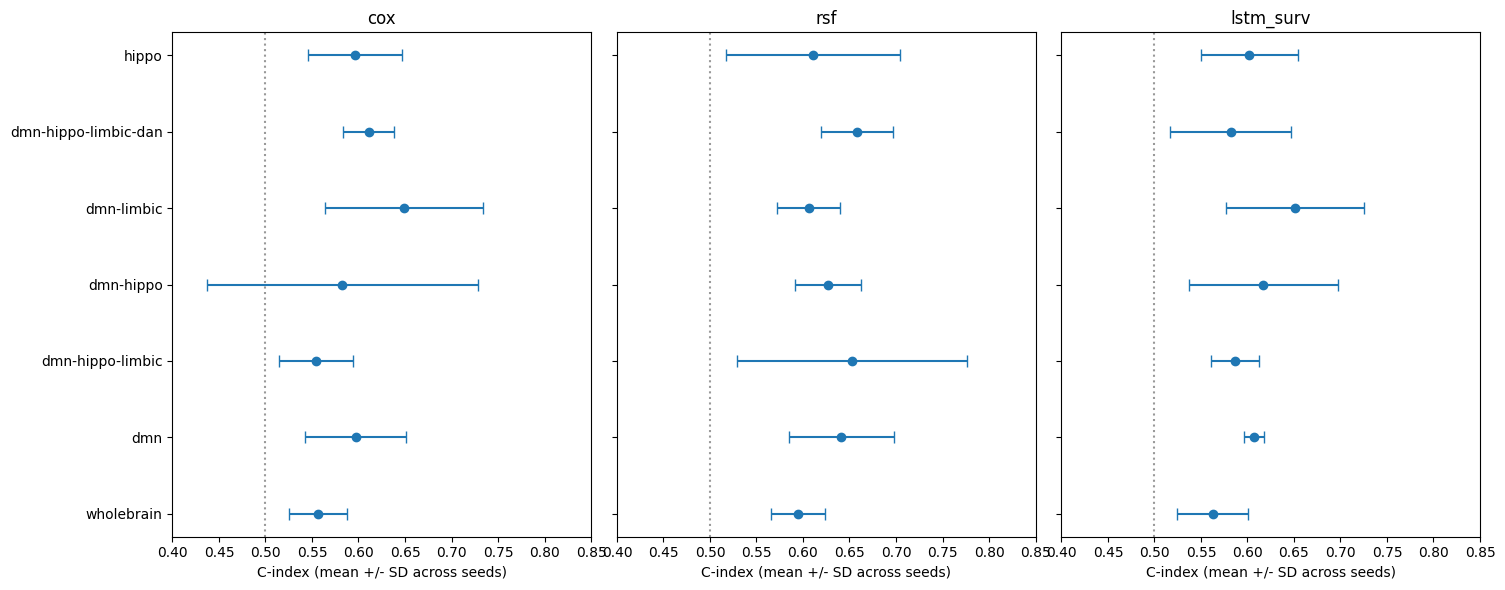

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, len(MODELS), figsize=(5 * len(MODELS), 6), sharey=True)
if len(MODELS) == 1:
    axes = [axes]
for ax, model in zip(axes, MODELS):
    sub = per_cell_summary[per_cell_summary["model"] == model].copy()
    sub = sub.set_index("region").reindex(REGIONS)
    y = np.arange(len(REGIONS))
    ax.errorbar(sub["c_mean"], y, xerr=sub["c_std"], fmt="o", capsize=4)
    ax.set_yticks(y); ax.set_yticklabels(REGIONS)
    ax.axvline(0.5, color="k", linestyle=":", alpha=0.4)
    ax.set_title(model); ax.set_xlabel("C-index (mean +/- SD across seeds)")
    ax.set_xlim(0.4, 0.85)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "forest_c_index.png", dpi=150)
plt.show()

## Summary

- `_results_survival/per_cell_c_index.csv` - mean +/- SD C-index per (model, region).
- `_results_survival/per_cell_td_auc.csv` - time-dependent AUC at 24/36/60 months.
- `_results_survival/contrast_table_c_index.csv` - 7 contrasts x model with delta-C-index, CI, Holm-adjusted p.
- `_results_survival/forest_c_index.png` - figure.

Switch `USE_MOCK = False` once PROGNOSER outputs exist.